## Import and setup

In [ ]:
# Installation libraries
%pip install iterative-stratification

import os
import re
import string
import random
import warnings
from collections import Counter
import joblib

import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, roc_auc_score, multilabel_confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.neighbors import NearestNeighbors

# NLP & Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# NLTK Setup
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Deep Learning (Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Bidirectional, Dropout, GRU,
    BatchNormalization, Conv1D, MaxPooling1D, GlobalMaxPooling1D
)
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.regularizers import l2

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Say NO to warnings!
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
RANDOM_SEED = 16
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Functions

### EDA Functions

In [ ]:
def eda_plots(df):
  """ View graphs on all toxicity labels """

  label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

  label_counts = df[label_cols].sum().sort_values(ascending=False)
  sum_inj_counts = df["sum_injurious"].value_counts().sort_index()
  sum_inj_counts_tox = df[df["sum_injurious"] > 0]["sum_injurious"].value_counts().sort_index()

  tox_vs_notox = np.array([
      (df["sum_injurious"] == 0).sum(),
      (df["sum_injurious"] >= 1).sum()
  ])

  fig, axes = plt.subplots(2, 2, figsize=(16, 10))
  ax1, ax2, ax3, ax4 = axes.flatten()

  # 1. Distribution of individual classes
  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", ax=ax1)
  ax1.set_title("Distribution of toxic classes")
  ax1.set_xlabel("Category")
  ax1.set_ylabel("Occurrences")

  # 2. Distribution of classes by comment
  sns.barplot(x=sum_inj_counts.index, y=sum_inj_counts.values, palette="viridis", ax=ax2)
  ax2.set_title("Distribution of classes by comment")
  ax2.set_xlabel("Nr. of classes")
  ax2.set_ylabel("Nr. of comments")

  # 3. Distribution of sum_injourious
  sns.barplot(x=sum_inj_counts_tox.index, y=sum_inj_counts_tox.values, palette="viridis", ax=ax3)
  ax3.set_title("Distribution of sum_injourious")
  ax3.set_xlabel("Nr. of toxic classes")
  ax3.set_ylabel("Nr. of comments")

  # 4. Toxic vs Non-Toxic
  sns.barplot(x=["Non-Toxic", "Toxic"], y=tox_vs_notox, palette="viridis", ax=ax4)
  ax4.set_title("Toxic vs Non-Toxic")
  ax4.set_xlabel("Type of comment")
  ax4.set_ylabel("Nr. of comments")

  for ax in axes.flatten():
      for p in ax.patches:
          height = p.get_height()
          ax.annotate(
              f"{int(height)}",
              (p.get_x() + p.get_width()/2, height),
              ha="center", va="bottom", fontsize=9
          )

  plt.tight_layout()
  plt.show()

In [ ]:
def correlation_matrix(df):
  ''' Heatmap of correlation between labels '''

  labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
  corr = df[labels].corr()

  plt.figure(figsize=(8,6))
  sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        cbar=True,
        square=True,
        linewidths=.5,
    )
  plt.title("Correlation Matrix")
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

In [ ]:
def mean_word_length(df):
    """ Function to analyze the length of comments in terms of word count, separating "hate" and "non-hate" comments """

    data = df.copy()
    data["comment_length"] = data["comment_text"].astype(str).apply(lambda x: len(x.split()))

    subsets = [
        ("All of comments", data),
        ("Non-Hate comments", data[data["sum_injurious"] == 0]),
        ("Hate comments", data[data["sum_injurious"] >= 1])
    ]

    colors = sns.color_palette("tab10", 3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (title, subset) in enumerate(subsets):
        sns.histplot(
            subset["comment_length"],
            bins=50,
            kde=True,
            color=colors[i],
            ax=axes[i]
        )
        axes[i].set_title(title)
        axes[i].set_xlabel("Number of words")
        axes[i].set_ylabel("Frequency")

    fig.suptitle("Word Count Distribution in Comments", fontsize=16, y=1.03)
    plt.tight_layout()

In [ ]:
def wordcloud_hate(df):
    """ Generate a wordcloud of hate comments """

    hate_text = df[df["sum_injurious"] >= 1]["comment_text"].dropna().astype(str)

    wc = WordCloud(
        width=800, height=400,
        background_color="black",
        max_words=200
    ).generate(" ".join(hate_text))

    plt.figure(figsize=(800/100, 400/100))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud - Hate Comments")
    plt.show()

### Pre Processing Function

In [ ]:
def text_preprocess(text):
    """
    Performs full text preprocessing:
      - lowercase
      - remove URL, HTML tags, digits, punctuation
      - normalize repeated letters
      - remove extra whitespaces
      - tokenize, stopwords removal, lemmatization
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URL
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # 3. Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # 4. Remove content between []
    text = re.sub(r"\[.*?\]", "", text)

    # 5. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 6. Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 7. Normalize repeated letters
    text = re.sub(r"(.)\1{2,}", r"\1", text)

    # 8. Replace newline with space
    text = text.replace("\n", " ")

    # 9. Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    # 10. Tokenization
    words = word_tokenize(text)

    # 11. Remove stopwords
    words = [w for w in words if w not in stop_words]

    # 12. Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

### Funzioni per i parametri

In [ ]:
def get_max_len(texts, percentile=75):
    """ Returns the recommended sequence length """
    lengths = texts.apply(lambda x: len(str(x).split()))
    max_len = int(np.percentile(lengths, percentile))

    print(f"MAX_LEN (percentile {percentile}): {max_len}")
    return max_len

In [ ]:
def get_max_words(texts, threshold=0.95):
    """ Calculate how many words in the vocabulary cover X% of the dataset """

    words = " ".join(texts.astype(str)).split()
    counts = Counter(words)

    sorted_counts = sorted(counts.values(), reverse=True)
    cumulative = np.cumsum(sorted_counts)

    total = cumulative[-1]
    limit = threshold * total

    max_words = np.argmax(cumulative >= limit) + 1
    print(f"VOCAB SIZE to cover {threshold*100:.0f}% of tokens: {max_words}")

    return max_words

### Funzioni per Undersampling

In [ ]:
def undersampling_neutral_comments(X_arr, y_arr, keep_ratio=0.4, random_state=RANDOM_SEED):
    """
    Undersampling comments with all labels = 0
    Keeps all toxic comments, reduces neutral ones
    """
    # Neutral mask
    neutral_mask = (y_arr == 0).all(axis=1)

    X_neutral = X_arr[neutral_mask]
    y_neutral = y_arr[neutral_mask]

    X_toxic = X_arr[~neutral_mask]
    y_toxic = y_arr[~neutral_mask]

    # Number of samples to keep
    n_keep = max(1, int(len(X_neutral) * keep_ratio))

    # Subsampling
    X_neutral_res, y_neutral_res = resample(
        X_neutral, y_neutral,
        replace=False,
        n_samples=n_keep,
        random_state=random_state
    )

    # Recombination
    X_under = np.vstack((X_toxic, X_neutral_res))
    y_under = np.vstack((y_toxic, y_neutral_res))

    # Final shuffle
    idx = np.random.permutation(len(X_under))
    X_under, y_under = X_under[idx], y_under[idx]

    print(f"New shape of X_under: {X_under.shape}, y_under: {y_under.shape}")

    pct_neutral = (y_under.sum(axis=1) == 0).mean()
    print(f"Percentage of Non-Hate after undersample: {pct_neutral:.2%}")

    return X_under, y_under

### Funzioni di valutazione

In [ ]:
def plot_learning_curve(history, metric='auc'):
    """
    Plot the learning curves:
    - Loss train/val
    - Metric chosen
    """

    hist = history.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(hist['loss'], label='Train Loss')
    axes[0].plot(hist['val_loss'], label='Val Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Metric
    axes[1].plot(hist[metric], label=f'Train {metric}')
    axes[1].plot(hist[f'val_{metric}'], label=f'Val {metric}')
    axes[1].set_title(f'{metric.upper()} (Train vs Val)')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel(metric.upper())
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_multilabel_model(y_true, y_pred, y_pred_proba=None):
    """
    Complete multilabel evaluation:
    - Accuracy multilabel
    - Precision micro/macro
    - F1 by class + F1 micro/macro
    - Classification report
    - AUC macro (if y_pred_proba available)
    """
    labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

    print("\nMultilabel Evalutaion")

    # 1. Accuracy multilabel
    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy multilabel (exact match): {acc:.4f}")

    # 2. Global Precision
    precision_micro = precision_score(y_true, y_pred, average="micro", zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\nPrecision micro: {precision_micro:.4f}")
    print(f"Precision macro: {precision_macro:.4f}")

    # 3. F1-score by class
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    print("\nF1-score by class:")
    for lbl, v in zip(labels, f1_per_class):
        print(f"    {lbl}: {v:.4f}")

    # 4. F1-score micro and macro
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\nF1 micro: {f1_micro:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")

    # 5. Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

    # 6. AUC (if available)
    if y_pred_proba is not None:
        try:
            auc_macro = roc_auc_score(y_true, y_pred_proba, average="macro")
            print(f"AUC macro: {auc_macro:.4f}")
        except:
            print("AUC not calculable")

### MLSMOTE

In [ ]:
class MLSMOTE:
    """
    Implementation of MLSMOTE for multilabel oversampling
    Generates new samples by interpolating features and combining labels
    """

    def __init__(self, k_neighbors=5, random_state=RANDOM_SEED):
        self.k_neighbors = k_neighbors
        self.random_state = random_state
        self.rs = np.random.RandomState(self.random_state)

    def fit_resample(self, X, y):
        n_samples = len(X)
        k = min(self.k_neighbors + 1, n_samples)

        nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
        nn.fit(X)

        neighbors = nn.kneighbors(X, return_distance=False)
        neighbors = neighbors[:, 1:] # removes itself

        # Identify positive samples (at least one label)
        minority_idx = np.where(y.sum(axis=1) > 0)[0]

        if len(minority_idx) == 0:
            return X, y

        n_new = len(minority_idx)
        X_new = np.zeros((n_new, X.shape[1]))
        y_new = np.zeros((n_new, y.shape[1]), dtype=int)

        # Synthetic sample generation
        for idx, i in enumerate(minority_idx):
            j = self.rs.choice(neighbors[i])
            lam = self.rs.random()

            X_new[idx] = X[i] + lam * (X[j] - X[i])
            y_new[idx] = np.logical_or(y[i], y[j]).astype(int)

        return np.vstack((X, X_new)), np.vstack((y, y_new))

In [ ]:
def apply_mlsmote(X, y, k_neighbors=5, random_state=None, shuffle=True):
    """ Applies MLSMOTE and optionally shuffles the final dataset """
    smote = MLSMOTE(k_neighbors=k_neighbors, random_state=random_state)
    X_res, y_res = smote.fit_resample(X, y)

    if shuffle:
        rng = np.random.default_rng(random_state)
        idx = rng.permutation(len(X_res))
        X_res, y_res = X_res[idx], y_res[idx]

    return X_res, y_res

## Dataset

In [ ]:
BASE_URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/"
df = pd.read_csv(BASE_URL + "Filter_Toxic_Comments_dataset.csv")

In [ ]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


In [ ]:
print("Examples of toxic comments:")
df[df['sum_injurious']>=1].head()

Examples of toxic comments:


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0,4
12,Hey... what is it..\n@ | talk .\nWhat is it......,1,0,0,0,0,0,1
16,"Bye! \n\nDon't look, come or think of comming ...",1,0,0,0,0,0,1
42,You are gay or antisemmitian? \n\nArchangel WH...,1,0,1,0,1,1,4
43,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1,0,1,0,1,0,3


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
 7   sum_injurious  159571 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 9.7+ MB
None


Il dataset contiene 159.571 osservazioni e 8 colonne, tutte relative a commenti online.

Ogni data point è composto da:

*   **comment_text**: il testo del commento;
*   6 variabili categoriali binarie: **toxic**, **severe_toxic**, **obscene**, **threat**, **insult**, **identity_hate**: viene assegnato 0 o 1 se il commento appartiene o meno alla categoria indicata;
*   **sum_injourious**: una variabile numerica discreta che assume valori interi da 0 a 6 e rappresenta la somma delle etichette presenti nelle sei colonne binarie.










## EDA

In [ ]:
print("Missing values: \n", df.isnull().sum())

Missing values: 
 comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
sum_injurious    0
dtype: int64


In [ ]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


All'interno del dataset non sono presenti né valori mancanti né duplicati.

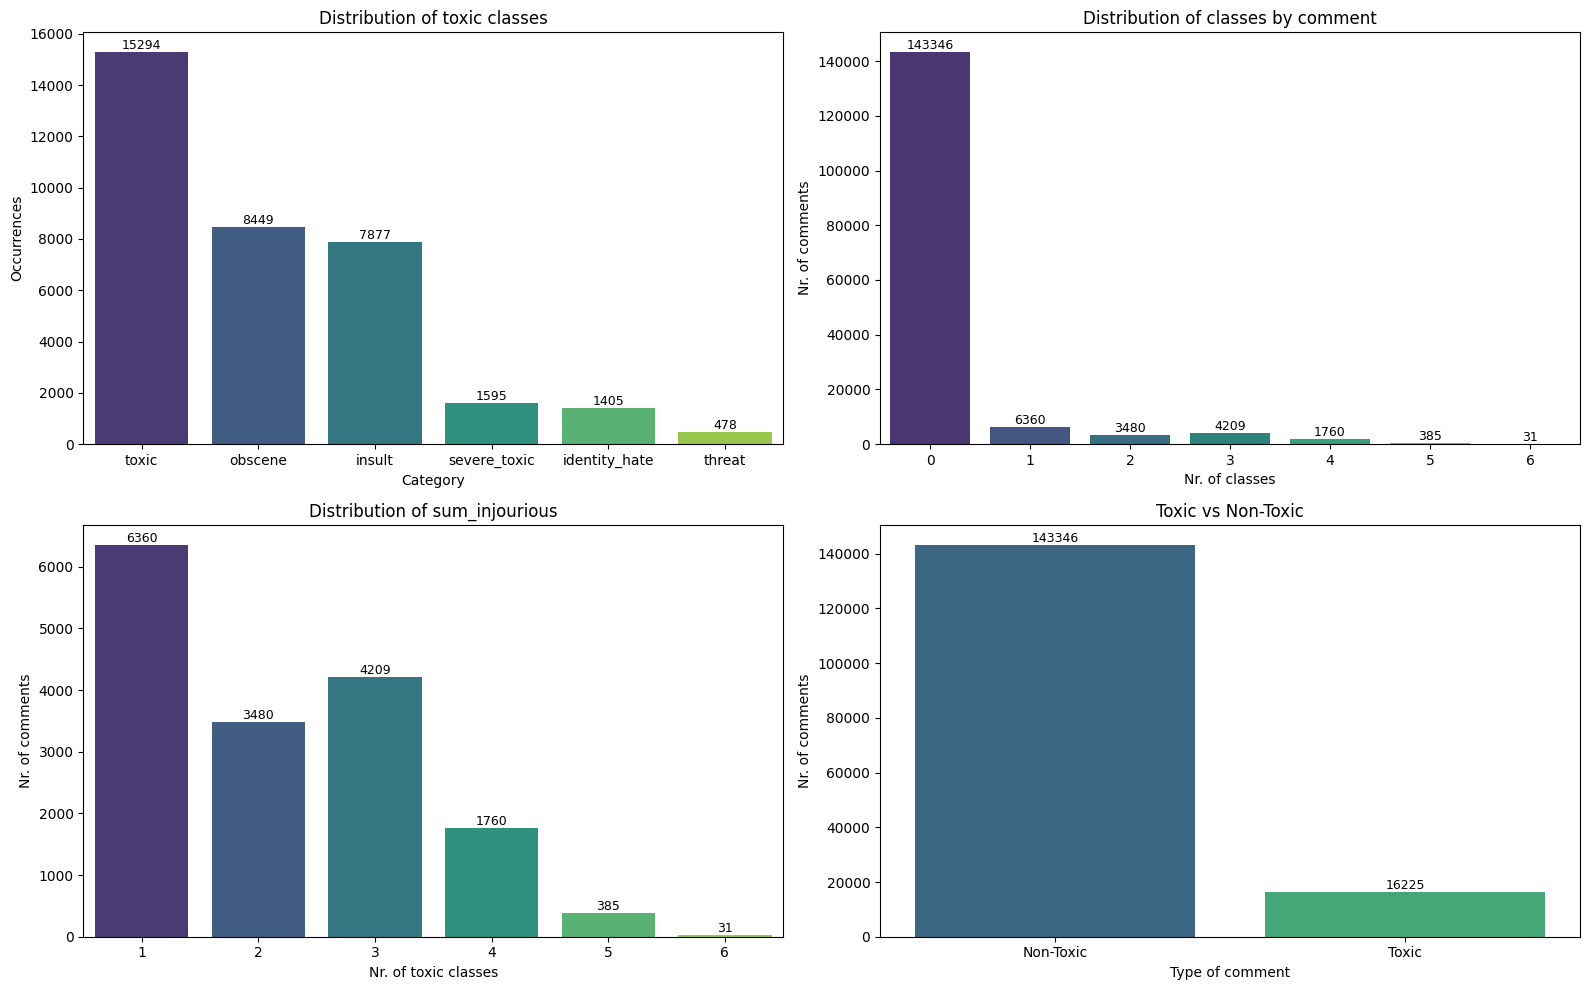

In [ ]:
eda_plots(df)

Per comprendere meglio la struttura del dataset e la distribuzione delle etichette tossiche, analizziamo questi quattro grafici:

*   **Distribution of toxic classes:** possiamo osservare come la maggior parte dei commenti (15.294 su 16.225, 94%) rientra nella categoria *“toxic”*. Possiamo quindi affermare che un commento di un hater viene quasi sempre classificato come toxic;
*   **Distribution of classes by comment:** il dataset si presenta fortemente sbilanciato in quanto la maggior parte dei commenti non presenta alcuna etichetta tossica (label 0);
*   **Distribution of sum_injourious:** la maggior parte dei commenti tossici ha una sola etichetta e i casi con più etichette diminuiscono rapidamente;
*   **Toxic vs Non-Toxic:** quasi il 90% dei commenti è Non-Toxic mentre i commenti Toxic rappresentano circa il 10%.

Il dataset presenta quindi un forte sbilanciamento, sia tra classi singole sia nella distribuzione multilabel.

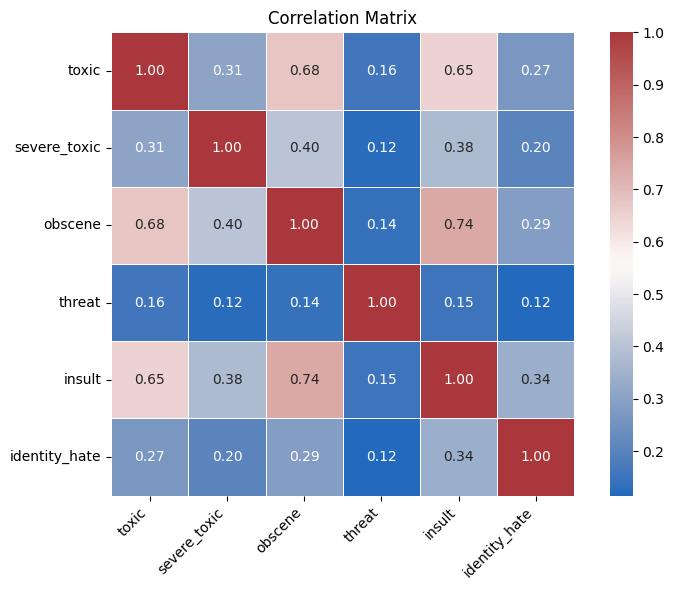

In [ ]:
correlation_matrix(df)

La matrice di correlazione conferma che alcune classi sono spesso presenti insieme (*insult, obscene, toxic*), mentre altre come *threat* e *identity_hate* sono molto più rare ed isolate.

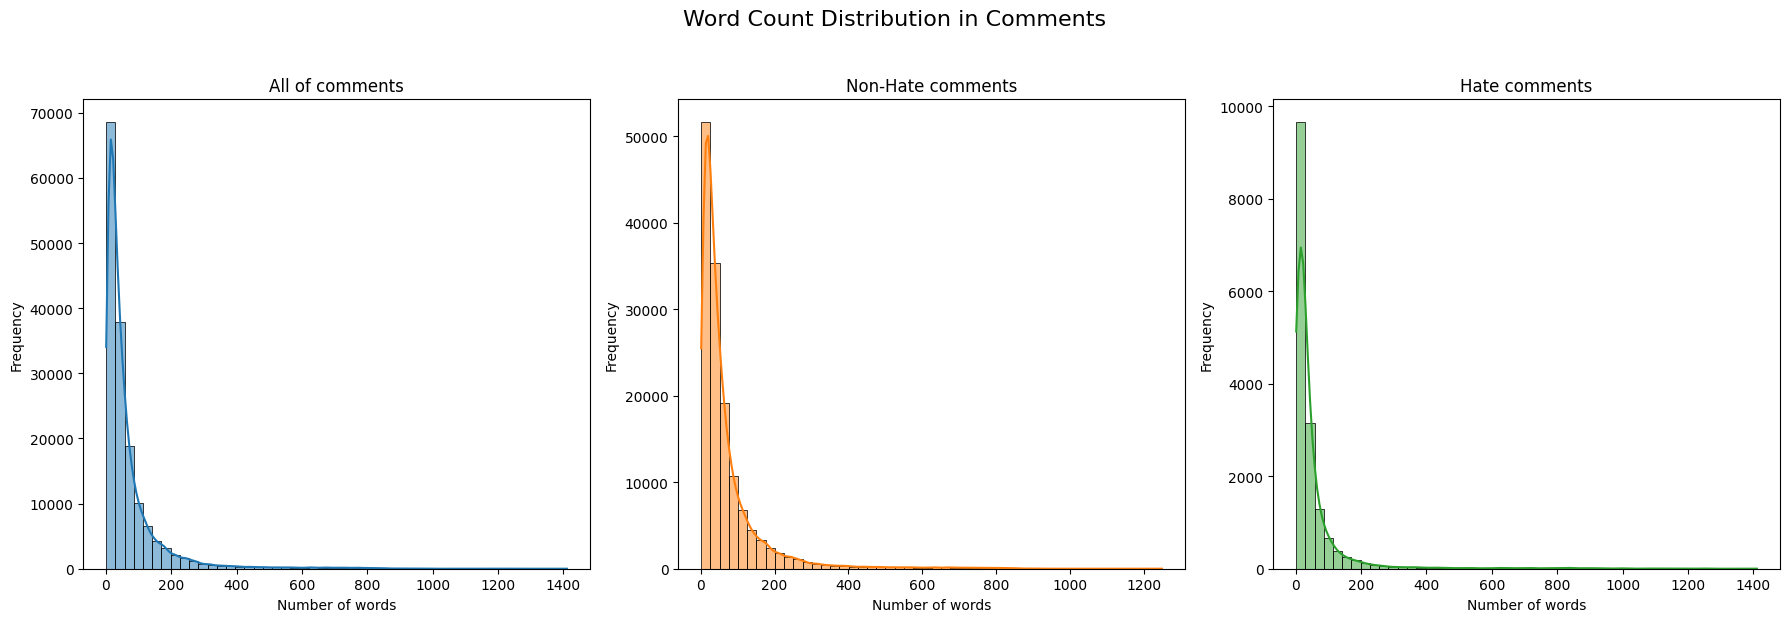

In [ ]:
mean_word_length(df)

Analizziamo la distribuzione delle parole all'interno dei commenti, distinguendo tra i commenti tossici e non tossici.

*   **All of commments:** notiamo come la distribuzione è fortemente asimmetrica verso destra, la maggior parte dei commenti contiene meno di 50 parole e solo una piccola parte supera le 200 parole. Sono presenti valori estremi che arrivano a oltre 1000 parole ma sono molto rari;
*   **Non-hate comments:** la lunghezza dei commenti non-hate è mediamente più breve rispetto ai commenti tossici;
*  **Hate comments**: anche qui la distribuzione è molto sbilanciata verso i testi corti, ma rispetto ai commenti non-hate si nota un picco più pronunciato per le lunghezze molto brevi (circa 5–15 parole).





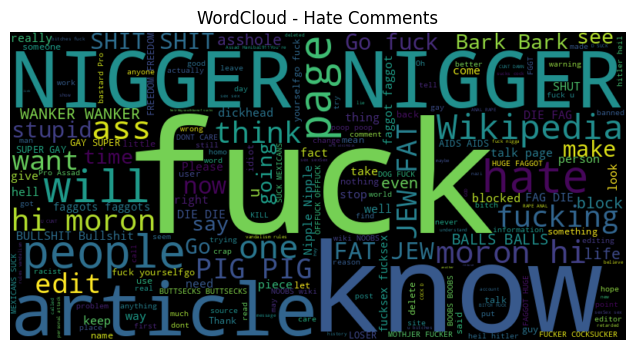

In [ ]:
wordcloud_hate(df)

Con questa WordCloud otteniamo una rappresentazione visiva della frequenza delle parole presenti all'interno dei commenti tossici, le parole che compaiono più spesso vengono visualizzate con dimensioni maggiori.

## Train Test Split

Procediamo separando il dataset in features (X) e target (y).

In [ ]:
X = df["comment_text"]
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (159571,)
y shape: (159571, 6)


Possiamo ora suddividere i dati in training e test, destinando il 20% dei campioni alla fase di valutazione e mantenendo le proporzioni di tutte le etichette grazie al **MultilabelStratifiedShuffleSplit**.

In [ ]:
# Train-Test Split Multilabel
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_SEED
)

for train_idx, test_idx  in msss.split(X, y):
    X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
    y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)

print(f"Shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Shape: X_test={X_test.shape}, y_test={y_test.shape}")

Shape: X_train=(127656,), y_train=(127656, 6)
Shape: X_test=(31915,), y_test=(31915, 6)


## Preprocessing

Con la funzione **text_preprocess** eliminiamo dai commenti gli elementi che non contribuiscono alla comprensione del loro contenuto. Le operazioni eseguite includono: conversione in lowercase, rimozione di URL, tag HTML, cifre e punteggiatura, normalizzazione delle lettere ripetute, eliminazione degli spazi extra, tokenizzazione, rimozione delle stopwords e lemmatizzazione.

In [ ]:
# Stopwords
stop_words = set(stopwords.words("english"))
stop_words -= {"not", "no", "never", "none", "without"}

lemmatizer = WordNetLemmatizer()

In [ ]:
# Preprocessing
X_train_proc = X_train.apply(text_preprocess)
X_test_proc = X_test.apply(text_preprocess)

print("Preprocessing example:\n")
print("Original:    ", X_train.iloc[2])
print("Preprocessed:", X_train_proc.iloc[2])

Preprocessing example:

Original:     Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.
Preprocessed: hey man im really not trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info


Una volta processati i testi dei commenti, analizziamo alcune loro proprietà per ottimizzare il flusso di lavoro e rendere l’intero processo più rapido ed efficiente.

Utilizziamo il 75° percentile come riferimento per definire la lunghezza delle sequenze su cui applicare il padding, questa scelta rappresenta un buon compromesso perchè consente di preservare la maggior parte delle informazioni senza penalizzare eccessivamente i commenti più brevi.
Inoltre dall’EDA era emerso che i commenti più lunghi risultavano spesso privi di etichette e che il dataset era fortemente sbilanciato in loro favore.

Per contenere la dimensione del vocabolario generato dalla tokenizzazione, analizziamo quante parole sono sufficienti a coprire il 95% del corpus e utilizziamo questo valore come limite massimo.

In [ ]:
# Calculate tokenizer/padding parameters
MAX_LEN = get_max_len(X_train_proc, percentile=75)
MAX_WORDS = get_max_words(X_train_proc, threshold=0.95)

MAX_LEN (percentile 75): 39
VOCAB SIZE to cover 95% of tokens: 30434


In [ ]:
# Tokenization
tokenizer = Tokenizer(num_words=MAX_WORDS+1, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_proc)

train_seq = tokenizer.texts_to_sequences(X_train_proc)
test_seq = tokenizer.texts_to_sequences(X_test_proc)

Procediamo con la tokenizzazione del testo impostando la dimensione del vocabolario a MAX_WORDS+1 (dove 1 è riservato al token di padding). Il tokenizer viene addestrato sul set di training e successivamente utilizziamo lo stesso per convertire in sequenze sia i commenti di train sia quelli di test.

In [ ]:
vocab_size = min(MAX_WORDS+1, len(tokenizer.word_index)+1)

print(f"Vocab size used: {vocab_size}")
print(f"Sequence length: {MAX_LEN}")

Vocab size used: 30435
Sequence length: 39


Applichiamo il padding alle sequenze per uniformarne la lunghezza.

In [ ]:
# Padding
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train shape after padding:", X_train_pad.shape)
print("X_Test shape after padding: ", X_test_pad.shape)

X_train shape after padding: (127656, 39)
X_Test shape after padding:  (31915, 39)


Convertiamo i target dei set di training e test in array NumPy, così da poterli utilizzare più facilmente nelle fasi successive di modellazione e addestramento.


In [ ]:
y_train_arr = y_train.values
y_test_arr = y_test.values

Come abbiamo osservato durate l'EDA abbiamo un dataset che presenta un forte sbilanciamento: circa il 90% dei data point non contiene alcuna etichetta (commenti Non-Hate).

Per affrontare questo problema applichiamo due tecniche di ricampionamento:

*   iniziamo con un’operazione di **undersampling**, riducendo il numero di commenti positivi per diminuire il divario rispetto ai commenti tossici;
*   successivamente utilizziamo anche una tecnica di **oversampling** per aumentare i data point appartenenti alle classi minoritarie nel set di training. Poiché ci troviamo in un contesto di classificazione multilabel, adottiamo l’algoritmo **MLSMOTE**, adatto a generare nuovi esempi sintetici rispettando la natura multilabel del problema.


In [ ]:
# Class Distribution Analysis
print("Class Distribution (Train)")
for name, count in zip(y_train.columns, y_train.sum().values):
    print(f"{name}: {count}")

non_hate_mask = (y_train.sum(axis=1) == 0)
non_hate_count = non_hate_mask.sum()

pct_non_hate = (y_train.sum(axis=1) == 0).mean()
print(f"\nNon-Hate percentage: {pct_non_hate:.2%}")

Class Distribution (Train)
toxic: 12235
severe_toxic: 1276
obscene: 6759
threat: 382
insult: 6302
identity_hate: 1124

Non-Hate percentage: 89.82%


In [ ]:
# Undersampling and MLSMOTE
X_under, y_under = undersampling_neutral_comments(
    X_train_pad,
    y_train_arr,
    keep_ratio=0.4
)

X_resampled, y_resampled = apply_mlsmote(
    X_under,
    y_under,
    k_neighbors=5,
    random_state=RANDOM_SEED
)

New shape of X_under: (58857, 39), y_under: (58857, 6)
Percentage of Non-Hate after undersample: 77.93%


In [ ]:
print("Final Distribution after resampling")
for name, count in zip(y_train.columns, y_train.sum().values):
    print(f"{name}: {count}")

pct_non_hate_new = (y_resampled.sum(axis=1) == 0).mean()
print(f"\nNon-Hate percentage after resampling: {pct_non_hate_new:.2%}")

print(f"\nX_resampled shape: {X_resampled.shape}")
print(f"y_resampled shape: {y_resampled.shape}")

Final Distribution after resampling
toxic: 12235
severe_toxic: 1276
obscene: 6759
threat: 382
insult: 6302
identity_hate: 1124

Non-Hate percentage after resampling: 63.84%

X_resampled shape: (71848, 39)
y_resampled shape: (71848, 6)


L’applicazione di **undersampling** e **MLSMOTE** riduce la percentuale di commenti privi di etichette dal 90% al 64%, rendendo il set di training significativamente più bilanciato. Questo intervento dovrebbe migliorare la capacità del modello di riconoscere le classi positive, anche se comporta un potenziale aumento del rischio di overfitting.

# Model

In [ ]:
# Hyperparameters
EMBEDDING_DIM = 128
NUM_CLASSES = y_train_arr.shape[1]
BATCH_SIZE = 32
EPOCHS = 16

In [ ]:
# Callback for early stopping
early_stopping_loss = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

early_stopping_f1 = EarlyStopping(
    monitor="val_precision",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

Partiamo con un modello ricorrente di tipo Vanilla.

In [ ]:
# RNN
RNN_model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dense(NUM_CLASSES, activation="sigmoid")
])

RNN_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.001),
    metrics=["accuracy", AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

RNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
RNN_history = RNN_model.fit(
    X_resampled, y_resampled,
    validation_data=(X_test_pad, y_test_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_loss],
    verbose=1
)

Epoch 1/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9429 - auc: 0.7698 - loss: 0.3449 - precision: 0.2804 - recall: 0.0297 - val_accuracy: 0.9878 - val_auc: 0.8844 - val_loss: 0.1220 - val_precision: 0.8437 - val_recall: 0.2037
Epoch 2/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9771 - auc: 0.8702 - loss: 0.2734 - precision: 0.7180 - recall: 0.3327 - val_accuracy: 0.9773 - val_auc: 0.9326 - val_loss: 0.0927 - val_precision: 0.6840 - val_recall: 0.4585
Epoch 3/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9705 - auc: 0.9225 - loss: 0.2183 - precision: 0.7643 - recall: 0.5310 - val_accuracy: 0.9780 - val_auc: 0.9341 - val_loss: 0.1097 - val_precision: 0.4896 - val_recall: 0.6021
Epoch 4/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9685 - auc: 0.9294 - loss: 0.2091 - precision: 0.7624 - recall: 0.5836 - val_accuracy: 0.9790 - val_auc: 0.9327 - val_loss: 0.1120 - val_precision: 0.4640 - val_recall: 0.6296
Epoch 5/16
2246/2246

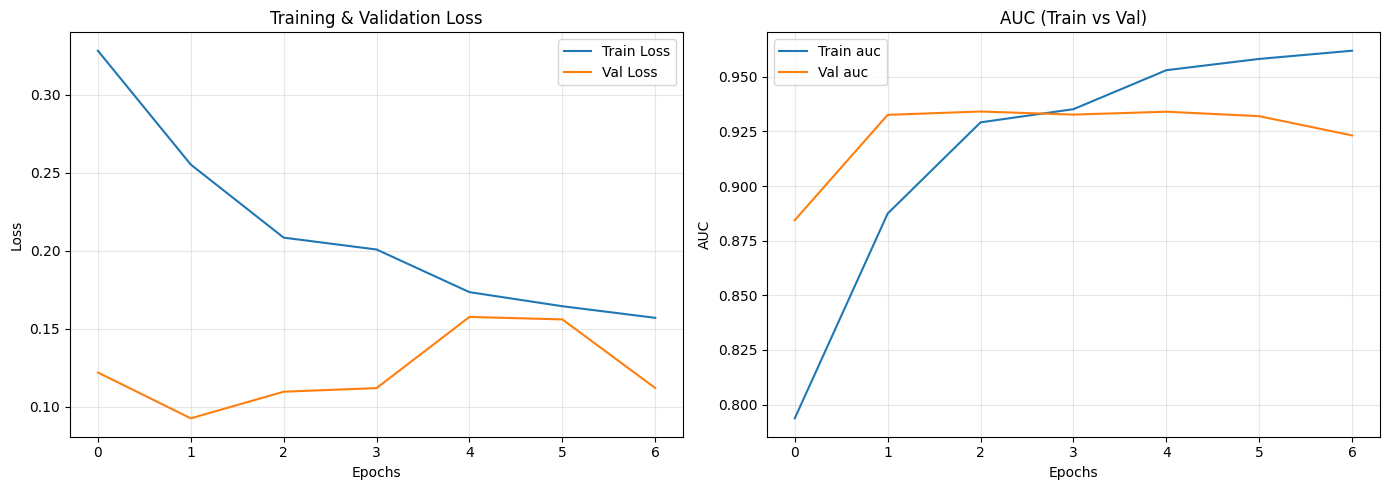

In [ ]:
plot_learning_curve(RNN_history, metric="auc")

In [ ]:
y_pred_proba_rnn = RNN_model.predict(X_test_pad)
y_pred_rnn = (y_pred_proba_rnn > 0.5).astype(int)

evaluate_multilabel_model(y_test_arr, y_pred_rnn, y_pred_proba_rnn)

998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Multilabel Evalutaion

Accuracy multilabel (exact match): 0.8849

Precision micro: 0.6840
Precision macro: 0.4947

F1-score by class:
    toxic: 0.5744
    severe_toxic: 0.0865
    obscene: 0.6240
    threat: 0.0000
    insult: 0.5577
    identity_hate: 0.0204

F1 micro: 0.5490
F1 macro: 0.3105

Classification Report:
               precision    recall  f1-score   support

        toxic       0.61      0.54      0.57      3059
 severe_toxic       0.54      0.05      0.09       319
      obscene       0.84      0.50      0.62      1690
       threat       0.00      0.00      0.00        96
       insult       0.75      0.44      0.56      1575
identity_hate       0.23      0.01      0.02       281

    micro avg       0.68      0.46      0.55      7020
    macro avg       0.49      0.26      0.31      7020
 weighted avg       0.67      0.46      0.53      7020
  samples avg       0.05      0.04      0.04      7020

AUC macro: 0.9040


L’RNN Vanilla mostra fin da subito alcuni limiti evidenti.

Dai grafici possiamo osservare che la training loss diminuisce in modo costante mentre la validation loss scende inizialmente per poi stabilizzarsi: un segnale che il modello inizia ad avvicinarsi all’overfitting. Lo stesso andamento emerge dall’AUC, indicando che il modello apprende schemi utili ma non generalizza completamente.

Anche le metriche multilabel confermano queste difficoltà: l’accuracy esatta risulta alta (0.8849), ma rimane un valore fuorviante perché il dataset è fortemente sbilanciato e predire molte etichette come negative porta comunque a risultati elevati. Gli F1-score, invece, mostrano la reale prestazione del modello: il micro F1 (0.5490) è moderato mentre il macro F1 (0.3105) è basso, evidenziando grandi differenze tra le classi. Gli F1 per classe sono invece molto eterogenei: buoni per toxic (0.5744), obscene (0.6240) e insult (0.5577), ma estremamente bassi per le classi meno rappresentate (threat = 0.0000, identity_hate = 0.0204, severe_toxic = 0.0865).

Nonostante un AUC macro molto buono (0.9040), che suggerisce una buona capacità discriminativa a livello continuo, il modello non riesce a tradurre questa abilità in predizioni binarie efficaci per tutte le classi, soprattutto per quelle più rare.

In [ ]:
# LSTM
LSTM_model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='sigmoid')
])

LSTM_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0005),
    metrics=["accuracy", AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

LSTM_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
LSTM_history = LSTM_model.fit(
    X_resampled, y_resampled,
    validation_data=(X_test_pad, y_test_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_loss],
    verbose=1
)

Epoch 1/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.7931 - auc: 0.7884 - loss: 0.3353 - precision: 0.5381 - recall: 0.2014 - val_accuracy: 0.9944 - val_auc: 0.9456 - val_loss: 0.1110 - val_precision: 0.7111 - val_recall: 0.5652
Epoch 2/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9432 - auc: 0.9107 - loss: 0.2296 - precision: 0.7613 - recall: 0.5023 - val_accuracy: 0.9944 - val_auc: 0.9520 - val_loss: 0.1132 - val_precision: 0.5383 - val_recall: 0.6870
Epoch 3/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9733 - auc: 0.9403 - loss: 0.1941 - precision: 0.7768 - recall: 0.6046 - val_accuracy: 0.9944 - val_auc: 0.9520 - val_loss: 0.1206 - val_precision: 0.4412 - val_recall: 0.7330
Epoch 4/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9798 - auc: 0.9557 - loss: 0.1704 - precision: 0.7942 - recall: 0.6737 - val_accuracy: 0.9942 - val_auc: 0.9450 - val_loss: 0.1258 - val_precision: 0.4013 - val_recall: 0.7120
Epoch 5/16
2246/

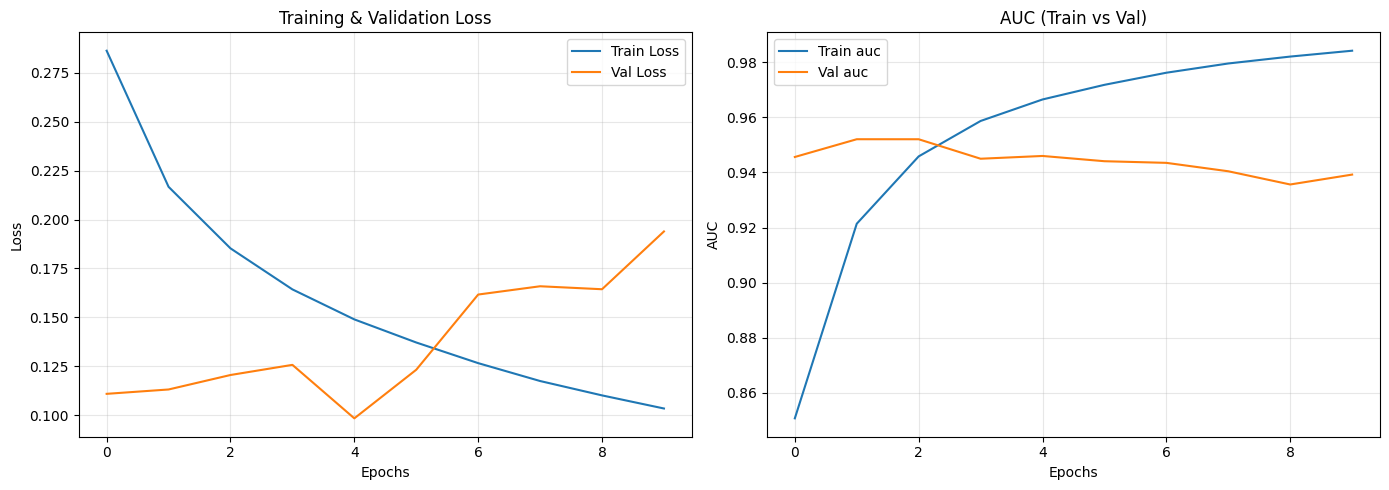

In [ ]:
plot_learning_curve(LSTM_history, metric="auc")

In [ ]:
y_pred_proba_lstm = LSTM_model.predict(X_test_pad)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

evaluate_multilabel_model(y_test_arr, y_pred_lstm, y_pred_proba_lstm)

998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Multilabel Evalutaion

Accuracy multilabel (exact match): 0.8572

Precision micro: 0.5050
Precision macro: 0.4091

F1-score by class:
    toxic: 0.5958
    severe_toxic: 0.4182
    obscene: 0.6460
    threat: 0.0583
    insult: 0.5588
    identity_hate: 0.0000

F1 micro: 0.5794
F1 macro: 0.3795

Classification Report:
               precision    recall  f1-score   support

        toxic       0.49      0.75      0.60      3059
 severe_toxic       0.50      0.36      0.42       319
      obscene       0.56      0.76      0.65      1690
       threat       0.43      0.03      0.06        96
       insult       0.47      0.69      0.56      1575
identity_hate       0.00      0.00      0.00       281

    micro avg       0.50      0.68      0.58      7020
    macro avg       0.41      0.43      0.38      7020
 weighted avg       0.49      0.68      0.56      7020
  samples avg       0.06      0.06      0.06      7020

AUC macro: 0.9361


Il modello LSTM mostra un comportamento migliore rispetto alla RNN vanilla.

Dai grafici emerge che la training loss diminuisce in modo costante mentre la validation loss rimane inizialmente più bassa e stabile per poi mostrare un incremento nelle ultime epoche, segnale di un overfitting moderato. Anche l’AUC conferma questo andamento: il valore in training cresce continuamente fino a superare 0.98, mentre quello di validation resta elevato e stabile.

Le metriche multilabel evidenziano un miglioramento rispetto alla RNN vanilla: l’F1 micro raggiunge 0.5794 e l’F1 macro 0.3795, riflettendo una maggiore capacità del modello di identificare correttamente le etichette positive. Le classi più frequenti: toxic (0.5958), obscene (0.6460) e insult (0.5588) ottengono performance solide e coerente mentre le classi meno rappresentate mostrano risultati più variabili: severe_toxic migliora sensibilmente (0.4182), threat rimane molto difficile da individuare (0.0583) e identity_hate risulta praticamente non riconosciuta (0.0000).

Il valore dell’AUC macro, pari a 0.9361, conferma l’ottima capacità discriminativa del modello, nettamente superiore alla RNN base. Nonostante i limiti persistenti sulle classi più rare, l’LSTM riesce a cogliere la struttura del problema multilabel in modo più efficace e a fornire predizioni complessivamente più robuste.

In [ ]:
# BiGRU
BiGRU_model = Sequential([
    Embedding(vocab_size, 100, input_length=MAX_LEN),
    Bidirectional(GRU(64, kernel_regularizer=l2(0.01))),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="sigmoid")
])

BiGRU_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0005),
    metrics=["accuracy", AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

BiGRU_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
BiGRU_history = BiGRU_model.fit(
    X_resampled, y_resampled,
    validation_data=(X_test_pad, y_test_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_f1],
    verbose=1
)

Epoch 1/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.8667 - auc: 0.7976 - loss: 0.7254 - precision: 0.5854 - recall: 0.1690 - val_accuracy: 0.9945 - val_auc: 0.9423 - val_loss: 0.1333 - val_precision: 0.6033 - val_recall: 0.6504
Epoch 2/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9580 - auc: 0.8986 - loss: 0.2473 - precision: 0.7544 - recall: 0.4564 - val_accuracy: 0.9945 - val_auc: 0.9488 - val_loss: 0.1109 - val_precision: 0.6128 - val_recall: 0.6766
Epoch 3/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9687 - auc: 0.9132 - loss: 0.2325 - precision: 0.7595 - recall: 0.5001 - val_accuracy: 0.9900 - val_auc: 0.9461 - val_loss: 0.1103 - val_precision: 0.5657 - val_recall: 0.6949
Epoch 4/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9743 - auc: 0.9279 - loss: 0.2170 - precision: 0.7698 - recall: 0.5436 - val_accuracy: 0.9787 - val_auc: 0.9394 - val_loss: 0.1068 - val_precision: 0.5704 - val_recall: 0.6796
Epoch 5/16
2246/

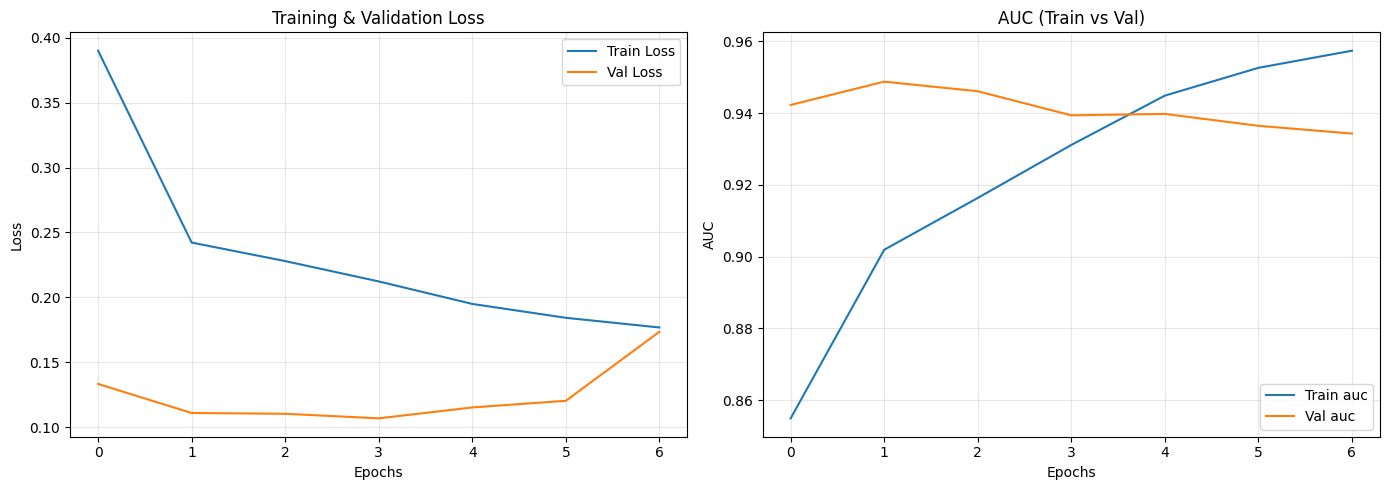

In [ ]:
plot_learning_curve(BiGRU_history, metric="auc")

In [ ]:
y_pred_proba_bigru = BiGRU_model.predict(X_test_pad)
y_pred_bigru = (y_pred_proba_bigru > 0.5).astype(int)

evaluate_multilabel_model(y_test_arr, y_pred_bigru, y_pred_proba_bigru)

998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Multilabel Evalutaion

Accuracy multilabel (exact match): 0.8703

Precision micro: 0.6128
Precision macro: 0.4338

F1-score by class:
    toxic: 0.6215
    severe_toxic: 0.1789
    obscene: 0.7651
    threat: 0.0000
    insult: 0.6872
    identity_hate: 0.0000

F1 micro: 0.6432
F1 macro: 0.3754

Classification Report:
               precision    recall  f1-score   support

        toxic       0.54      0.74      0.62      3059
 severe_toxic       0.66      0.10      0.18       319
      obscene       0.73      0.80      0.77      1690
       threat       0.00      0.00      0.00        96
       insult       0.67      0.70      0.69      1575
identity_hate       0.00      0.00      0.00       281

    micro avg       0.61      0.68      0.64      7020
    macro avg       0.43      0.39      0.38      7020
 weighted avg       0.59      0.68      0.62      7020
  samples avg       0.06      0.06      0.06      7020

AUC macro: 0.9370


Il modello BiGRU mostra un andamento della loss piuttosto stabile: la training loss diminuisce in modo costante mentre quella di validation rimane inizialmente più bassa e mostra un leggero aumento nelle ultime epoche, segnale di un principio di overfitting. L’AUC segue un comportamento simile: cresce progressivamente nel training e rimane elevata sulla validazione, pur evidenziando un piccolo calo nelle epoche finali.

Le metriche multilabel confermano le buone prestazioni del modello: l’F1 micro raggiunge 0.6432, il valore più alto tra quelli ottenuti finora, mentre l’F1 macro è pari a 0.3754. Le classi più frequenti: toxic (0.6215), obscene (0.7651) e insult (0.6872) ottengono F1 molto solidi, dimostrando che il modello riesce a riconoscere efficacemente le categorie principali. Le classi meno rappresentate continuano invece a creare difficoltà: severe_toxic (0.1789), threat e identity_hate ottengono F1 pari a 0.0000, confermando la complessità del task sulle classi più rare.

Il valore dell’AUC macro, pari a 0.9370, indica un’eccellente capacità discriminativa, comparabile a quella dell’LSTM. Nel complesso, il BiGRU rappresenta un’ulteriore evoluzione in termini di performance: riesce a cogliere meglio le strutture testuali bidirezionali e produce predizioni più efficaci soprattutto nelle classi più frequenti, pur mantenendo le stesse difficoltà sulle categorie minoritarie.

In [ ]:
# Double BiGRU
BiGRU_2layer_model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(GRU(64, return_sequences=True, kernel_regularizer=l2(0.01))),
    Dropout(0.5),
    BatchNormalization(),
    Bidirectional(GRU(64, kernel_regularizer=l2(0.01))),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="sigmoid",)
])

BiGRU_2layer_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0005),
    metrics=["accuracy", AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

BiGRU_2layer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
BiGRU_2layer_history = BiGRU_2layer_model.fit(
    X_resampled, y_resampled,
    validation_data=(X_test_pad, y_test_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_f1],
    verbose=1
)

Epoch 1/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 64s 26ms/step - accuracy: 0.8092 - auc: 0.8270 - loss: 1.2728 - precision: 0.6162 - recall: 0.2876 - val_accuracy: 0.9945 - val_auc: 0.9507 - val_loss: 0.1110 - val_precision: 0.7420 - val_recall: 0.6241
Epoch 2/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9410 - auc: 0.9072 - loss: 0.2416 - precision: 0.7575 - recall: 0.4971 - val_accuracy: 0.9943 - val_auc: 0.9424 - val_loss: 0.1493 - val_precision: 0.4505 - val_recall: 0.7208
Epoch 3/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9530 - auc: 0.9475 - loss: 0.1964 - precision: 0.7918 - recall: 0.6497 - val_accuracy: 0.9943 - val_auc: 0.9162 - val_loss: 0.2002 - val_precision: 0.2670 - val_recall: 0.7037
Epoch 4/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9643 - auc: 0.9634 - loss: 0.1700 - precision: 0.8207 - recall: 0.7217 - val_accuracy: 0.9942 - val_auc: 0.9335 - val_loss: 0.1722 - val_precision: 0.3205 - val_recall: 0.7363
Epoch 5/16
2246/

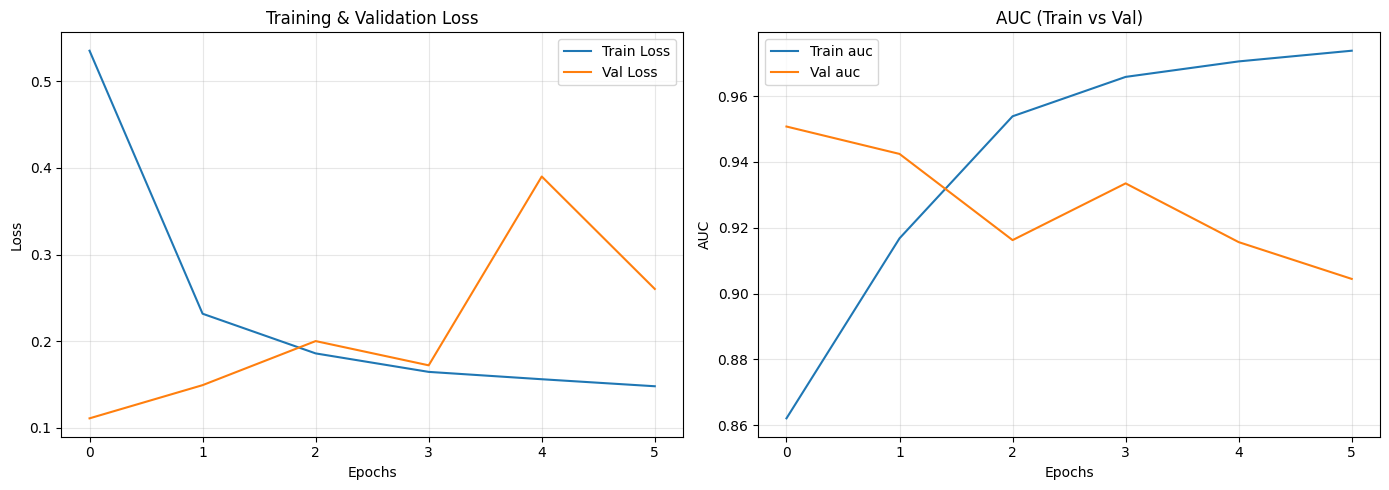

In [ ]:
plot_learning_curve(BiGRU_2layer_history, metric="auc")

In [ ]:
y_pred_proba_bigru2 = BiGRU_2layer_model.predict(X_test_pad)
y_pred_bigru2 = (y_pred_proba_bigru2 > 0.5).astype(int)

evaluate_multilabel_model(y_test_arr, y_pred_bigru2, y_pred_proba_bigru2)

998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

Multilabel Evalutaion

Accuracy multilabel (exact match): 0.9014

Precision micro: 0.7420
Precision macro: 0.4820

F1-score by class:
    toxic: 0.7013
    severe_toxic: 0.2864
    obscene: 0.7763
    threat: 0.0000
    insult: 0.6634
    identity_hate: 0.0000

F1 micro: 0.6780
F1 macro: 0.4046

Classification Report:
               precision    recall  f1-score   support

        toxic       0.71      0.69      0.70      3059
 severe_toxic       0.63      0.18      0.29       319
      obscene       0.81      0.74      0.78      1690
       threat       0.00      0.00      0.00        96
       insult       0.73      0.61      0.66      1575
identity_hate       0.00      0.00      0.00       281

    micro avg       0.74      0.62      0.68      7020
    macro avg       0.48      0.37      0.40      7020
 weighted avg       0.70      0.62      0.65      7020
  samples avg       0.06      0.06      0.06      7020

AUC macro: 0.9323


Il modello Double BiGRU mostra un comportamento più instabile rispetto alle architetture precedenti.

La training loss diminuisce in modo regolare mentre la validation loss presenta oscillazioni marcate tra un’epoca e l’altra, questo andamento suggerisce un processo di apprendimento meno stabile e una tendenza all’overfitting già nelle prime fasi del training. Anche l’AUC riflette questo comportamento: cresce costantemente sul training set, mentre sulla validation mostra oscillazioni più pronunciate, pur mantenendosi su valori complessivamente alti.

Le metriche multilabel evidenziano buone prestazioni complessive, con miglioramenti rilevanti rispetto ai modelli precedenti: l’F1 micro raggiunge 0.6780, il valore più alto ottenuto finora, mentre l’F1 macro è pari a 0.4046. In particolare: toxic (0.7013), obscene (0.7763) e insult (0.6634) mostrano valori di F1 molto competitivi mentre le classi meno frequenti rimangono problematiche: severe_toxic ottiene un risultato moderato (0.2864), threat e identity_hate restano con F1 pari a 0.0000.

Il valore dell’AUC macro, pari a 0.9323, conferma una buona capacità discriminativa, tuttavia la forte instabilità mostrata dalla loss di validazione indica che la maggiore complessità dell’architettura non si traduce automaticamente in una generalizzazione più stabile o affidabile.

In [ ]:
# Hybrid model: CNN + BiLSTM
CNN_BiLSTM_model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    Conv1D(64, 3, activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling1D(2),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="sigmoid")
])

CNN_BiLSTM_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0005),
    metrics=["accuracy", AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

CNN_BiLSTM_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
CNN_BiLSTM_history = CNN_BiLSTM_model.fit(
    X_resampled, y_resampled,
    validation_data=(X_test_pad, y_test_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_f1],
    verbose=1
)

Epoch 1/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.7669 - auc: 0.8206 - loss: 0.3184 - precision: 0.5910 - recall: 0.2949 - val_accuracy: 0.9945 - val_auc: 0.9573 - val_loss: 0.1071 - val_precision: 0.6278 - val_recall: 0.7095
Epoch 2/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9640 - auc: 0.9307 - loss: 0.2137 - precision: 0.7675 - recall: 0.5588 - val_accuracy: 0.9945 - val_auc: 0.9562 - val_loss: 0.0972 - val_precision: 0.5500 - val_recall: 0.7078
Epoch 3/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9801 - auc: 0.9592 - loss: 0.1715 - precision: 0.7996 - recall: 0.6863 - val_accuracy: 0.9944 - val_auc: 0.9587 - val_loss: 0.1050 - val_precision: 0.4743 - val_recall: 0.7444
Epoch 4/16
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9815 - auc: 0.9728 - loss: 0.1441 - precision: 0.8297 - recall: 0.7516 - val_accuracy: 0.9943 - val_auc: 0.9557 - val_loss: 0.1175 - val_precision: 0.4326 - val_recall: 0.7614
Epoch 5/16
2246/

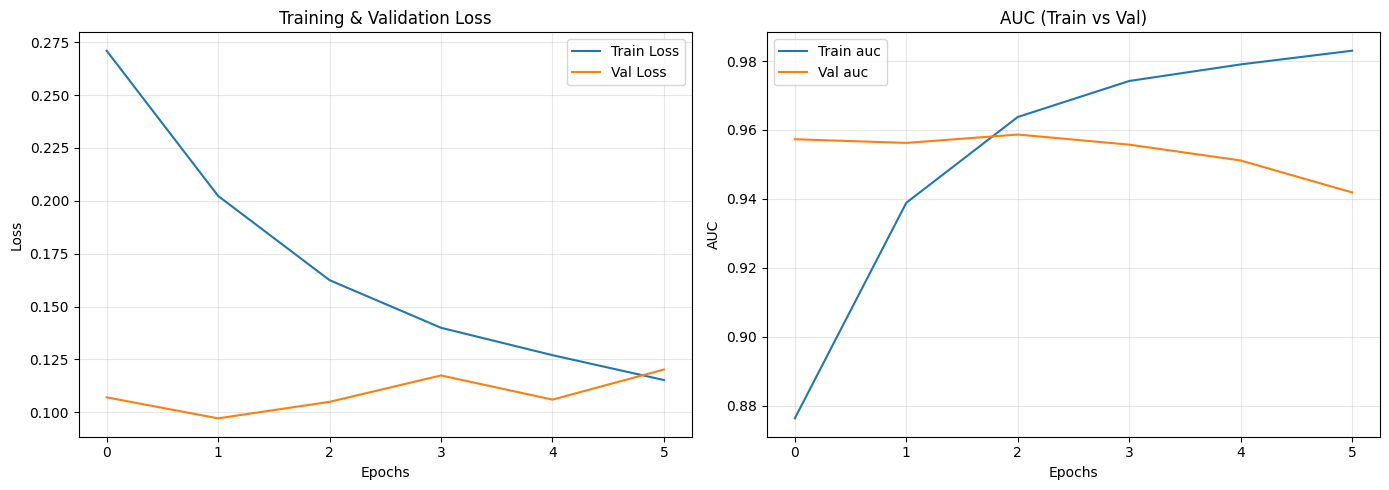

In [ ]:
plot_learning_curve(CNN_BiLSTM_history, metric="auc")

In [ ]:
y_pred_proba_cnn_bilstm = CNN_BiLSTM_model.predict(X_test_pad)
y_pred_cnn_bilstm = (y_pred_proba_cnn_bilstm > 0.5).astype(int)

evaluate_multilabel_model(y_test_arr, y_pred_cnn_bilstm, y_pred_proba_cnn_bilstm)

998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Multilabel Evalutaion

Accuracy multilabel (exact match): 0.8740

Precision micro: 0.6278
Precision macro: 0.4225

F1-score by class:
    toxic: 0.6501
    severe_toxic: 0.4744
    obscene: 0.7904
    threat: 0.0000
    insult: 0.6847
    identity_hate: 0.0000

F1 micro: 0.6662
F1 macro: 0.4333

Classification Report:
               precision    recall  f1-score   support

        toxic       0.55      0.79      0.65      3059
 severe_toxic       0.52      0.44      0.47       319
      obscene       0.78      0.80      0.79      1690
       threat       0.00      0.00      0.00        96
       insult       0.68      0.69      0.68      1575
identity_hate       0.00      0.00      0.00       281

    micro avg       0.63      0.71      0.67      7020
    macro avg       0.42      0.45      0.43      7020
 weighted avg       0.61      0.71      0.65      7020
  samples avg       0.07      0.07      0.06      7020

AUC macro: 0.9440


Il modello CNN_BiLSTM mostra un andamento molto regolare durante l’addestramento.

La training loss diminuisce in modo costante mentre la validation loss rimane stabile nelle prime epoche e mostra solo un leggero aumento finale, segnale di un overfitting limitato. L’AUC conferma questa tendenza: cresce progressivamente sul training set e rimane elevata anche sulla validation, pur con un lieve calo nelle ultime epoche.

Le metriche multilabel confermano le ottime prestazioni del modello: l’F1 micro raggiunge 0.6662 mentre l’F1 macro arriva a 0.4333. Le classi più rappresentate: toxic (0.6501), obscene (0.7904) e insult (0.6847) ottengono risultati molto solidi, mostrando che il modello riesce a riconoscere con efficacia le categorie più comuni. Anche severe_toxic mostra un miglioramento rilevante (0.4744), pur rimanendo una classe complessa da individuare.

Le principali difficoltà si osservano, come nei modelli precedenti, nelle classi molto rare: threat e identity_hate ottengono F1 pari a zero, evidenziando che la combinazione CNN + BiLSTM non riesce ancora a catturare queste categorie con pochissimi esempi nel dataset. Tuttavia, il valore dell’AUC macro, pari a 0.9440, evidenzia un’eccellente capacità discriminativa complessiva.

Per concludere, il modello CNN_BiLSTM si dimostra particolarmente efficace nel riconoscimento delle classi più comuni e presenta un buon equilibrio tra capacità di apprendimento e generalizzazione, risultando una delle architetture più solide tra quelle analizzate.

In [ ]:
best_model = CNN_BiLSTM_model

# Save and load model

In [ ]:
MODEL_PATH = "toxicity_model.keras"
TOKENIZER_PATH = "tokenizer.joblib"

# Save model
best_model.save(MODEL_PATH)
print(f"Model saved in: {MODEL_PATH}")

# Save tokenizer
joblib.dump(tokenizer, TOKENIZER_PATH)
print(f"Tokenizer saved in: {TOKENIZER_PATH}")

Model saved in: toxicity_model.keras
Tokenizer saved in: tokenizer.joblib


In [ ]:
model = load_model(MODEL_PATH)
tokenizer = joblib.load(TOKENIZER_PATH)

print("Model and tokenizer loaded successfully!")

Model and tokenizer loaded successfully!


# Testing

In [ ]:
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [ ]:
def predict_text(text, model, tokenizer, maxlen=MAX_LEN, labels=LABELS, threshold=0.5):
    """
    Preprocesses a text, generates multilabel predictions and returns:
    - probability
    - binary labels (0/1)
    """
    # Preprocess + tokenize
    processed = text_preprocess(text)
    seq = tokenizer.texts_to_sequences([processed])
    pad_seq = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')

    pad_seq = np.array(pad_seq)

    # Prediction
    proba = model.predict(pad_seq)[0]
    preds = (proba > threshold).astype(int)

    results = {label: float(prob) for label, prob in zip(labels, proba)}
    binary = {label: int(pred) for label, pred in zip(labels, preds)}

    return results, binary

In [ ]:
def print_prediction_output(proba_dict, binary_dict):
    """ Multilabel prediction printing. """

    print("\nMultilabel predictions:")
    for label in proba_dict:
        print(f"    {label:15s}: {proba_dict[label]:.4f}")

    binary_vector = list(binary_dict.values())
    print("\nBinary vector:", binary_vector)

In [ ]:
# Example 1
sample_text_1 = "Fuck you! Son of a bitch, I hate you!"

proba_1, binary_1 = predict_text(
    sample_text_1,
    model=best_model,
    tokenizer=tokenizer,
    maxlen=MAX_LEN
)

print("\nText:", sample_text_1)
print_prediction_output(proba_1, binary_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

Text: Fuck you! Son of a bitch, I hate you!

Multilabel predictions:
    toxic          : 0.9966
    severe_toxic   : 0.5915
    obscene        : 0.9642
    threat         : 0.0259
    insult         : 0.8995
    identity_hate  : 0.1713

Binary vector: [1, 1, 1, 0, 1, 0]


In [ ]:
# Example 2
sample_text_2 = "You are a stupid worthless loser, go disappear already."

proba_2, binary_2 = predict_text(
    sample_text_2,
    model=best_model,
    tokenizer=tokenizer,
    maxlen=MAX_LEN
)

print("\nText:", sample_text_2)
print_prediction_output(proba_2, binary_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Text: You are a stupid worthless loser, go disappear already.

Multilabel predictions:
    toxic          : 0.9289
    severe_toxic   : 0.2024
    obscene        : 0.6982
    threat         : 0.0329
    insult         : 0.5993
    identity_hate  : 0.1357

Binary vector: [1, 0, 1, 0, 1, 0]


In [ ]:
# Example 3
sample_text_3 = "This is disgusting. People like you don’t deserve to be here."

proba_3, binary_3 = predict_text(
    sample_text_3,
    model=best_model,
    tokenizer=tokenizer,
    maxlen=MAX_LEN
)

print("\nText:", sample_text_3)
print_prediction_output(proba_3, binary_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Text: This is disgusting. People like you don’t deserve to be here.

Multilabel predictions:
    toxic          : 0.8726
    severe_toxic   : 0.1451
    obscene        : 0.5700
    threat         : 0.0362
    insult         : 0.5313
    identity_hate  : 0.1153

Binary vector: [1, 0, 1, 0, 1, 0]


In [ ]:
# Example 4
sample_text_4 = "Great job on your presentation today, you explained everything clearly!"

proba_4, binary_4 = predict_text(
    sample_text_4,
    model=best_model,
    tokenizer=tokenizer,
    maxlen=MAX_LEN
)

print("\nText:", sample_text_4)
print_prediction_output(proba_4, binary_4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Text: Great job on your presentation today, you explained everything clearly!

Multilabel predictions:
    toxic          : 0.3407
    severe_toxic   : 0.0386
    obscene        : 0.1878
    threat         : 0.0152
    insult         : 0.2043
    identity_hate  : 0.0529

Binary vector: [0, 0, 0, 0, 0, 0]


In [ ]:
# Example 5
sample_text_5 = "Thanks for the help earlier, I really appreciate your support."

proba_5, binary_5 = predict_text(
    sample_text_5,
    model=best_model,
    tokenizer=tokenizer,
    maxlen=MAX_LEN
)

print("\nText:", sample_text_5)
print_prediction_output(proba_5, binary_5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Text: Thanks for the help earlier, I really appreciate your support.

Multilabel predictions:
    toxic          : 0.0940
    severe_toxic   : 0.0078
    obscene        : 0.0490
    threat         : 0.0023
    insult         : 0.0533
    identity_hate  : 0.0099

Binary vector: [0, 0, 0, 0, 0, 0]


L’analisi dei cinque testi di prova mostra una netta distinzione tra contenuti altamente offensivi e messaggi positivi.

Nei primi due testi, caratterizzati da un linguaggio chiaramente tossico e ricco di espressioni volgari, il modello assegna probabilità molto elevate alle categorie toxic, obscene e insult con valori significativi anche per severe_toxic (rispettivamente 0.5915 e 0.2024). Le categorie threat e identity_hate risultano invece meno marcate, in linea con l’assenza di minacce esplicite o riferimenti diretti a gruppi identitari.

Il terzo testo, pur mantenendo un tono denigratorio e sgradevole, presenta un’intensità leggermente inferiore: il modello rileva toxic e insult ma con valori più contenuti rispetto ai testi più aggressivi, generando un vettore binario meno “pesante” ma comunque indicativo della natura offensiva del contenuto.

I testi 4 e 5, dal tono positivo e apprezzativo, mostrano probabilità molto basse in tutte le categorie di tossicità. Il modello riconosce correttamente l’assenza di elementi offensivi, assegnando un vettore completamente nullo per entrambi i casi, anche se nel testo 4 alcune categorie mostrano valori leggermente più alti pur restando ampiamente al di sotto della soglia.

Complessivamente, i risultati indicano che il sistema è in grado di distinguere con buona precisione diversi livelli di tossicità, riconoscendo sia l’intensità sia la natura delle espressioni offensive e mantenendo al tempo stesso un comportamento affidabile sui commenti neutri o positivi.